<h1>Импорт библиотек

In [4]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [6]:
def sum_prod(X, V):
    '''
    X - матрицы (n, n)
    V - векторы (n, 1)
    Гарантируется, что len(X) == len(V)
    '''
    # Your code goes here
    result = np.zeros_like(V[0])
    for i in range(len(X)):
      result += X[i] @ V[i]
    return result


X = [np.array([[1,2],[3,4]]), np.array([[0,1],[1,0]])]
V = [np.array([[1],[2]]), np.array([[3],[4]])]
assert np.allclose(sum_prod(X, V), np.array([[9],[14]]))

<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [7]:
def binarize(M, threshold=0.5):
    return (M > threshold).astype(int)


M = np.array([[0.2,0.7],[0.5,0.9]])
assert np.array_equal(binarize(M, threshold=0.5), np.array([[0,1],[0,1]]))
assert np.array_equal(binarize(M, threshold=0.2), np.array([[0,1],[1,1]]))

<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [8]:
def unique_rows(mat):
    '''
    Возвращает список np.array с уникальными элементами по каждой строке
    '''
    return [np.unique(row) for row in mat]

def unique_columns(mat):
    '''
    Возвращает список np.array с уникальными элементами по каждому столбцу
    '''
    return [np.unique(mat[:, j]) for j in range(mat.shape[1])]

# Тесты
mat = np.array([
    [1,2,2],
    [3,3,4]
])

rows = unique_rows(mat)
cols = unique_columns(mat)

assert all(np.array_equal(r, e) for r, e in zip(rows, [np.array([1,2]), np.array([3,4])]))
assert all(np.array_equal(c, e) for c, e in zip(cols, [np.array([1,3]), np.array([2,3]), np.array([2,4])]))

<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

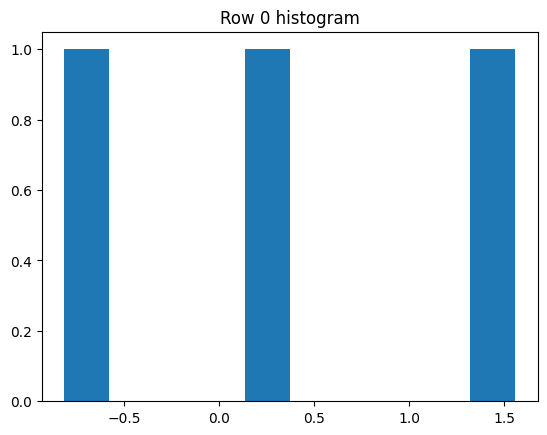

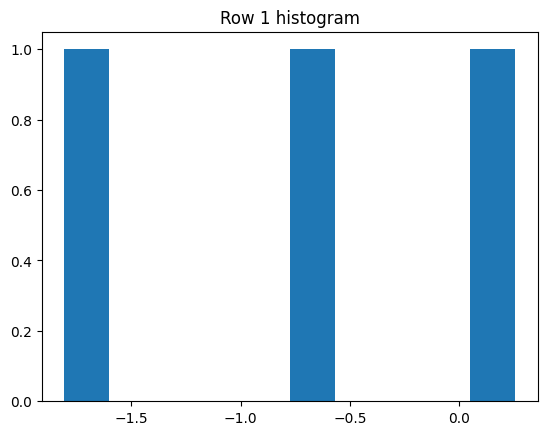

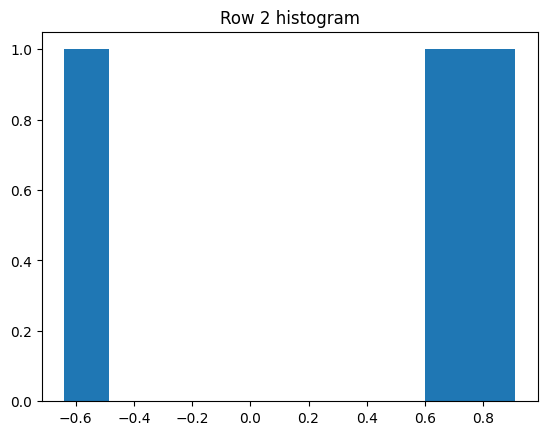

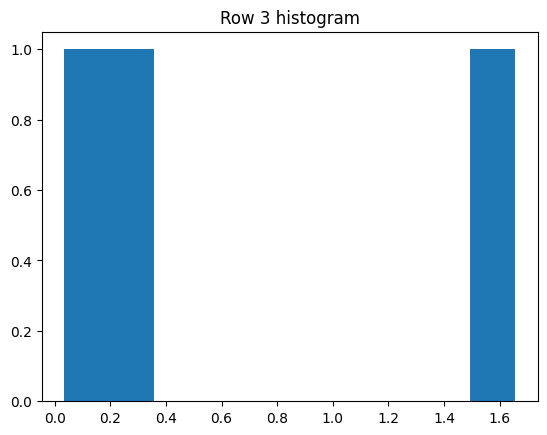

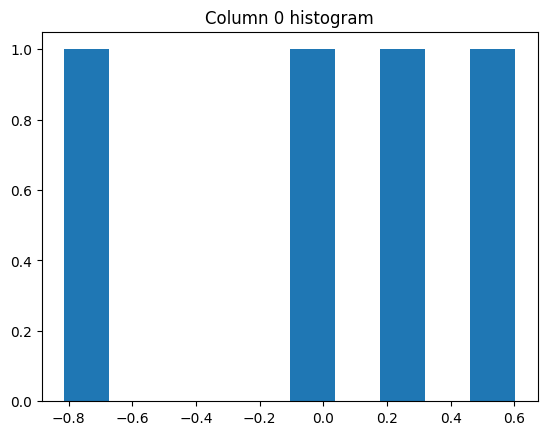

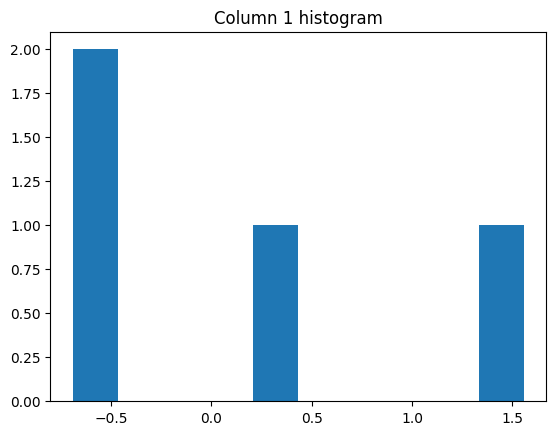

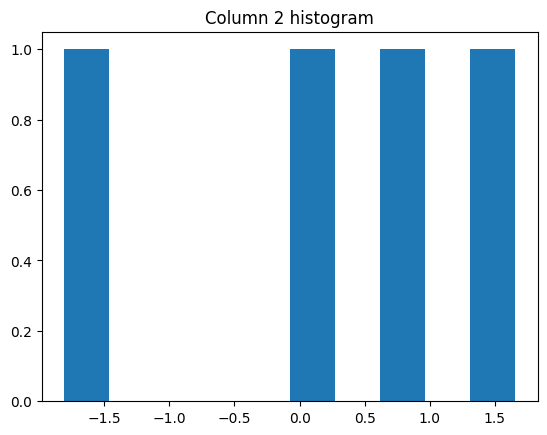

(array([[-0.81358938,  1.55742996,  0.23373845],
       [ 0.25623864, -0.68823178, -1.8073084 ],
       [ 0.60226958, -0.63868323,  0.90940551],
       [ 0.03451127,  0.34421072,  1.65598243]]), array([ 0.32585967, -0.74643385,  0.29099729,  0.67823481]), array([0.94119861, 0.71139814, 0.44787501, 0.49398083]), array([0.01985753, 0.14368142, 0.2479545 ]), array([0.27248208, 0.83576774, 1.66109195]))


In [9]:
def random_matrix_stats(m, n):
    mat = np.random.normal(loc=0.0, scale=1.0, size=(m, n))
    row_means = mat.mean(axis=1)
    row_vars = mat.var(axis=1)
    col_means = mat.mean(axis=0)
    col_vars = mat.var(axis=0)

    # Гистограммы строк
    for i in range(m):
        plt.hist(mat[i], bins=10)
        plt.title(f"Row {i} histogram")
        plt.show()

    # Гистограммы столбцов
    for j in range(n):
        plt.hist(mat[:, j], bins=10)
        plt.title(f"Column {j} histogram")
        plt.show()

    return mat, row_means, row_vars, col_means, col_vars

print(random_matrix_stats(4, 3))

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [10]:
def chess(m, n, a, b):
    '''
    Создаёт шахматную матрицу размера (m x n) с чередующимися значениями a и b
    '''
    mat = np.zeros((m, n), dtype=type(a))
    for i in range(m):
        for j in range(n):
            mat[i, j] = a if (i + j) % 2 == 0 else b
    return mat

# Тесты
expected = np.array([
    [1,0,1],
    [0,1,0]
])
assert np.array_equal(chess(2,3,1,0), expected)

<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

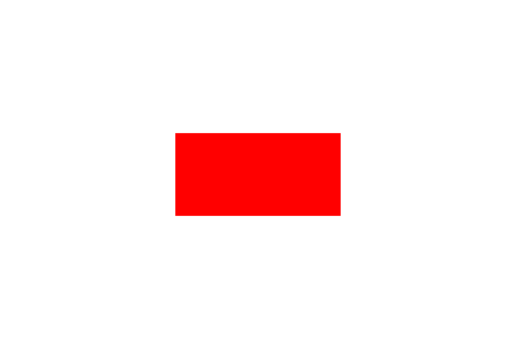

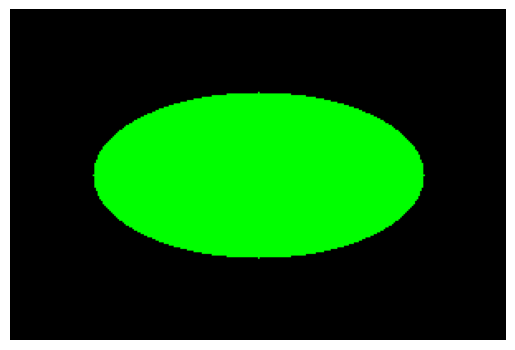

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(200, 300, 3), dtype=uint8)

In [11]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    start_x = (m - a) // 2
    start_y = (n - b) // 2
    img[start_x:start_x+a, start_y:start_y+b] = rectangle_color
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    return img

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    Y, X = np.ogrid[:m, :n]
    center_x, center_y = m / 2, n / 2
    mask = (((X - center_y) / b)**2 + ((Y - center_x) / a)**2) <= 1
    img[mask] = ellipse_color
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    return img

# Тесты (визуальные)
draw_rectangle(50, 100, 200, 300, [255,0,0], [255,255,255])
draw_ellipse(50, 100, 200, 300, [0,255,0], [0,0,0])


<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [12]:
def time_series_analysis(series, window):
    mean = np.mean(series)
    var = np.var(series)
    std = np.std(series)

    maxima = []
    minima = []
    for i in range(1, len(series)-1):
        if series[i] > series[i-1] and series[i] > series[i+1]:
            maxima.append(i)
        if series[i] < series[i-1] and series[i] < series[i+1]:
            minima.append(i)

    moving_avg = np.convolve(series, np.ones(window)/window, mode='valid')

    return mean, var, std, maxima, minima, moving_avg


# Тесты
s = np.array([1,3,2,4,3,5,4])
mean, var, std, maxima, minima, ma = time_series_analysis(s, 3)
assert np.isclose(mean, np.mean(s))
assert np.isclose(var, np.var(s))
assert maxima == [1,3,5]
assert minima == [2,4]


<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [13]:
def one_hot_encode(labels):
    num_classes = np.max(labels) + 1
    return np.eye(num_classes, dtype=int)[labels]

# Тесты
labels = np.array([0,2,3,0])
expected = np.array([
    [1,0,0,0],
    [0,0,1,0],
    [0,0,0,1],
    [1,0,0,0]
])
assert np.array_equal(one_hot_encode(labels), expected)
